In [1]:
# 1. Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
# 2. Load Dataset

df = pd.read_csv("Advertising.csv")
df


,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [3]:
df.head()

,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.drop('ID', axis=1,inplace=True)

In [5]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [6]:
# 3. Dataset Information
# Shows number of rows and columns.

df.shape

(200, 4)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
# Statistical Summary
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
# 4. Data Cleaning
# Check Missing Values

df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [10]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

In [12]:
# 5. Exploratory Data Analysis
# Correlation Between Variables

df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


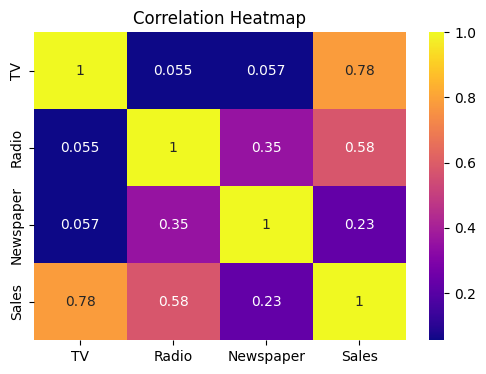

In [13]:
# Heatmap visualization:
# This shows how strongly TV, Radio, Newspaper affect Sales.

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="plasma")
plt.title("Correlation Heatmap")
plt.show()

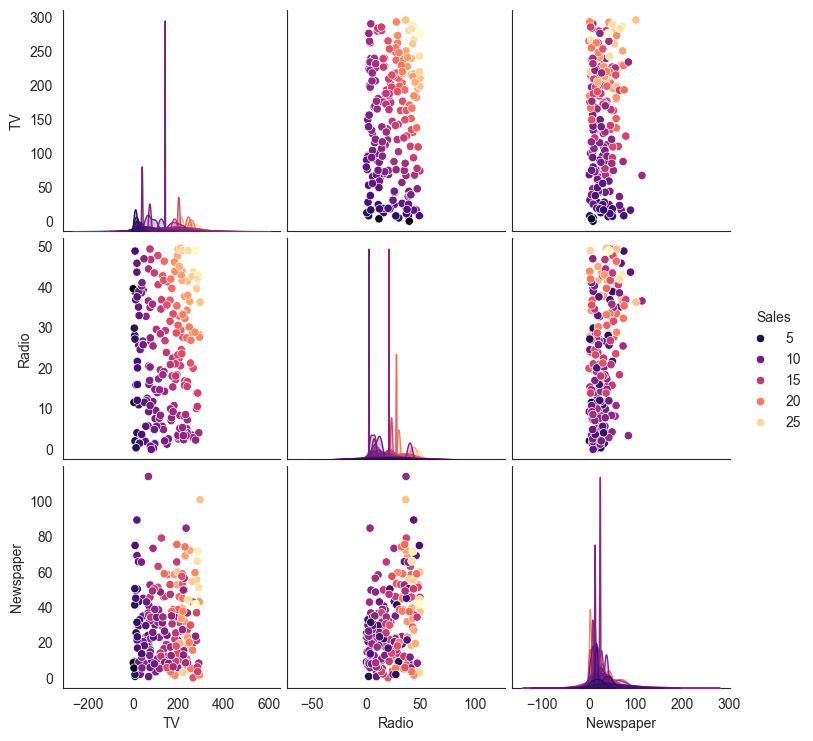

In [14]:
# Pairplot visualization
# This shows relationships between all variables.
sns.set_style("white")
sns.pairplot(df, hue='Sales', palette='magma')
plt.show()

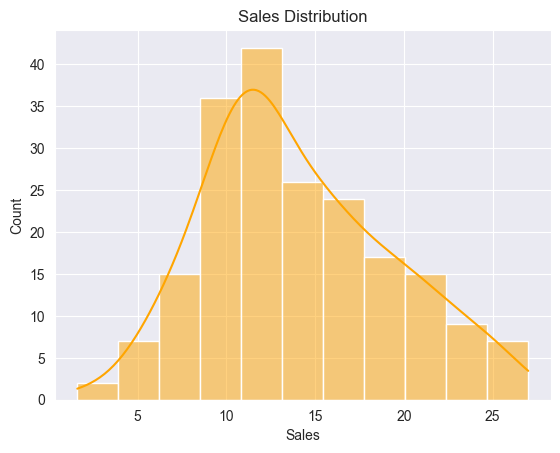

In [15]:
# Distribution Plot (Sales)
# shows how sales values are distributed

sns.set_style("darkgrid")
sns.histplot(df['Sales'], kde=True, color='orange')
plt.title("Sales Distribution")
plt.show()

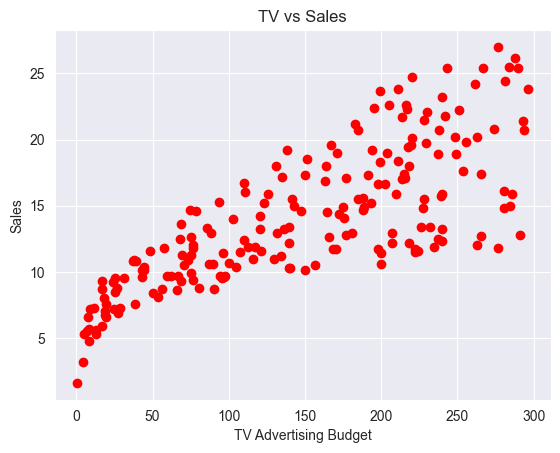

In [16]:
# Scatter Plot (TV vs Sales)
sns.set_style("darkgrid")
plt.scatter(df['TV'], df['Sales'], color='red')
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

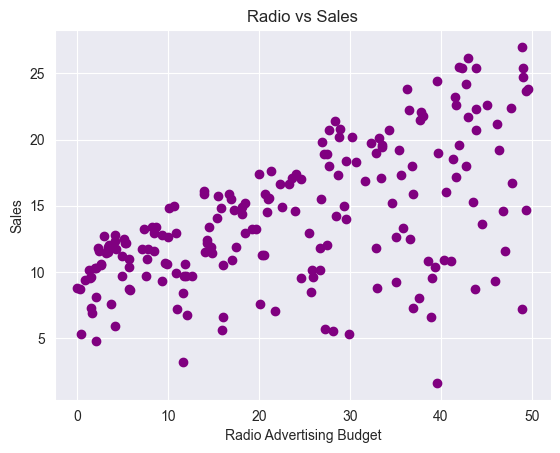

In [17]:
# Scatter Plot (Radio vs Sales)

plt.scatter(df['Radio'], df['Sales'],color='purple')
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

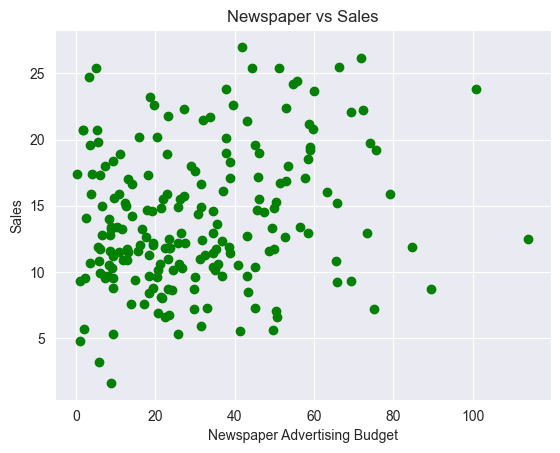

In [18]:
# Scatter Plot (Newspaper vs Sales)

plt.scatter(df['Newspaper'], df['Sales'],color='green')
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()

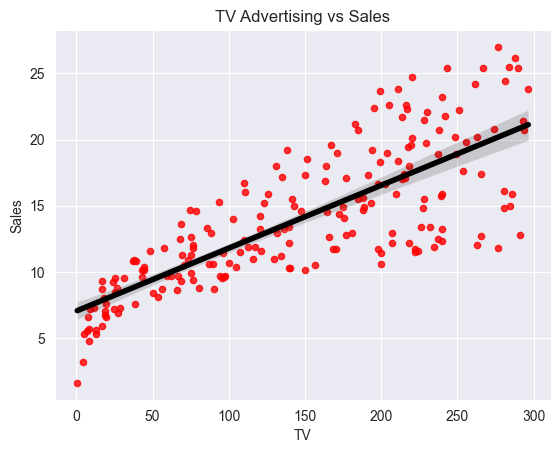

In [19]:
# Regression plots (TV Advertising vs Sales)

sns.regplot(x='TV', y='Sales', data=df, scatter_kws={'color':'red' , 's':20},
    line_kws={'color':'black', 'linewidth':4})
plt.title("TV Advertising vs Sales")
plt.show()


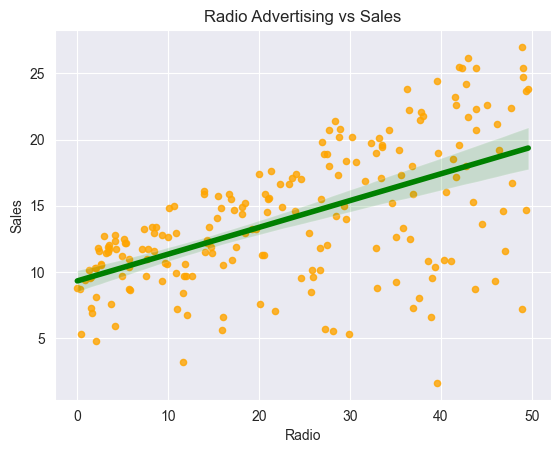

In [20]:
# Regression plots (Radio Advertising vs Sales)
sns.regplot(x='Radio', y='Sales', data=df, scatter_kws={'color':'orange' , 's':20},
    line_kws={'color':'green', 'linewidth':4})
plt.title("Radio Advertising vs Sales")
plt.show()

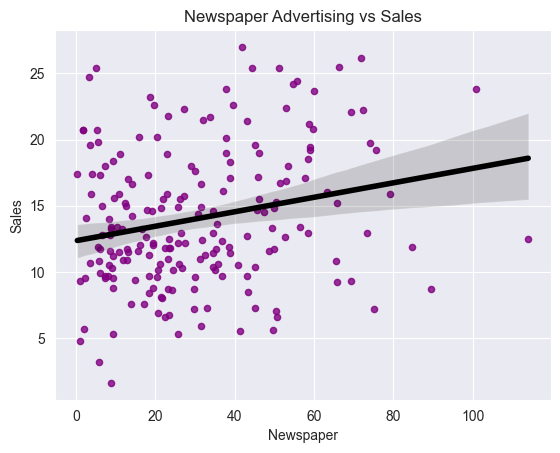

In [21]:
# Regression plots (Newspaper Advertising vs Sales)

sns.regplot(x='Newspaper', y='Sales', data=df, scatter_kws={'color':'purple', 's':20},
    line_kws={'color':'black', 'linewidth':4})
plt.title("Newspaper Advertising vs Sales")
plt.show()

In [22]:
# 6. Feature Selection
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

In [23]:
# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# 8. Polynomial Regression Model
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()

model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# 9. Model Prediction
y_pred = model.predict(X_test_poly)

In [26]:
# 10. Model Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nModel Evaluation")

print("R2 Score (Accuracy):", r2)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)



Model Evaluation
R2 Score (Accuracy): 0.9869181490609598
Mean Squared Error: 0.4129102285379215
Root Mean Squared Error: 0.642580912055378


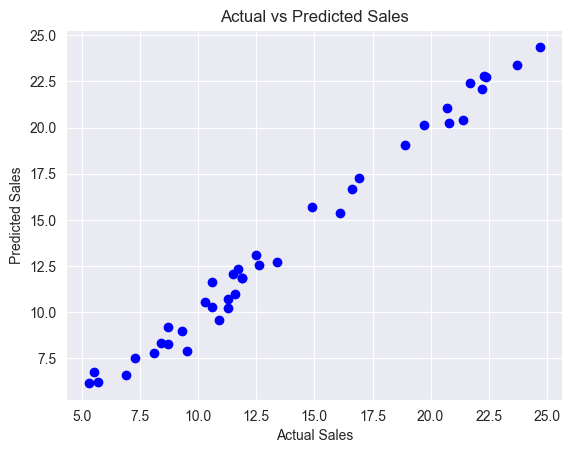

In [27]:
# 11. Actual vs Predicted Plot
# If points are close to a straight line, the model performs well.

plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


In [28]:
# 12. Sales Prediction (New Data)
tv_ads = 230
radio_ads = 37
newspaper_ads = 69

input_data = [[tv_ads, radio_ads, newspaper_ads]]

input_poly = poly.transform(input_data)

predicted_sales = model.predict(input_poly)

print("\nPredicted Sales:", predicted_sales[0])


Predicted Sales: 21.525067057386618


c:\Users\SUNIL\OneDrive\Desktop\Data_Science\demo\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
